
<style>
  .capa{max-width:920px;margin:16px auto;padding:24px;border:1px solid #e5e7eb;border-radius:12px;font-family:system-ui,-apple-system,"Segoe UI",Roboto,Arial,sans-serif;color:#1f2937}
  .topo{display:flex;gap:16px;align-items:center}
  .logo{width:120px;height:auto;border:1px solid #e5e7eb;border-radius:6px;padding:6px;background:#fff}
  h1{margin:0 0 4px 0;font-size:24px;color:#111827}
  .sub{color:#6b7280;margin-bottom:10px}
  .meta{display:flex;flex-wrap:wrap;gap:8px;margin-bottom:12px}
  .pill{font-size:12px;padding:6px 10px;border:1px solid #e5e7eb;border-radius:999px;background:#f3f4f6}
  hr{border:none;border-top:1px solid #e5e7eb;margin:14px 0}
  h2{font-size:16px;margin:0 0 6px 0;color:#111827}
  ul{margin:6px 0 0 18px}
</style>

<div class="capa" role="region" aria-label="Capa UFMG">
  <div class="topo">
    <img class="logo" src="logo_ufmg.png" alt="Logo UFMG">
    <div>
      <h1>TCC — Análise Descritiva de Preços de Combustíveis (ANP)</h1>
      <div class="sub">Universidade Federal de Minas Gerais — Nota sobre viés e limitações</div>
      <div class="meta">
        <span class="pill">Autoria: <b>Marina Ferreira</b></span>
        <span class="pill">Orientação: <b>Profa. Dra. Jussiane</b></span>
        <span class="pill">Versão 1.0</span>
      </div>
    </div>
  </div>

  <hr>

  <h2>Introdução</h2>
  <p>Este caderno consolida estatísticas descritivas de <em>preços de combustíveis</em> ao longo dos anos,
  com granularidade principal <b>anual</b> e recortes por <b>produto</b> e por <b>espaço</b> (regiões, UFs, municípios).
  O objetivo é apoiar a narrativa de eventos de mercado e políticas públicas que possam ter influenciado
  essas variações.</p>

  <h2>Principais vieses e limitações</h2>
  <ul>
    <li><b>Agregação anual</b> suaviza choques intra-ano; usarei também série mensal.</li>
    <li><b>Cobertura amostral</b> desigual entre UFs/municípios/produtos (impacta comparabilidade).</li>
    <li><b>Rotatividade de postos</b> altera o mix de observações (viés de sobrevivência).</li>
    <li><b>Erros de medição</b> podem persistir mesmo após filtros de outliers.</li>
    <li><b>Tributos e políticas</b> não são controlados automaticamente; interpretar com contexto.</li>
    <li><b>Heterogeneidade espacial</b> (logística/concorrência/renda) afeta níveis de preço.</li>
    <li><b>Composição por produto</b> (ex.: aditivados) influencia médias.</li>
      <li><b>Comparativo de preço de compra com venda</b> não tem registro suficiente de preço de compra e também não tem registro para todos os anos parando em 2020. Por isso a coluna não será usada.</li>
  </ul>

  <h2>Notas metodológicas (resumo)</h2>
  <ul>
    <li>Limpeza monetária (R$) e padronização decimal.</li>
    <li>Cálculos por <em>ano × produto</em> e recortes espaciais; média, mediana, desvio-padrão, p10, p90, IQR e <i>n</i>.</li>
    <li>Outliers por IQR apenas para diagnóstico.</li>
    <li>Mapas com <code>geopandas</code> + <code>geobr</code>; <i>join</i> municipal por nome dentro da UF.</li>
    <li>Série mensal disponível para anotar eventos (políticas/choques).</li>
     <li>Código comentado por IA.</li>
  </ul>
</div>


In [1]:
import pandas as pd
import folium
#import great_expectations
from pathlib import Path
from zipfile import ZipFile
import os
from pathlib import Path
from typing import Optional, Sequence
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from scipy import stats

from statsmodels.api import OLS, add_constant
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from patsy import dmatrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy.contrasts import Treatment
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

# Configuração do Notebook
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.mode.chained_assignment = None
pd.set_option("display.width", 120)

In [2]:
def check_cols(df, columns=None):
    """
    Returns a summary of column properties: dtype, unique values, number and percentage of NaNs.

    Parameters:
    - df (pd.DataFrame): The dataframe to inspect.
    - columns (list or None): Subset of columns to check. If None, checks all columns.

    Returns:
    - pd.DataFrame: A summary dataframe sorted by the number of NaN values.
    """
    if columns is None:
        columns = df.columns

    nunique_safe = df[columns].apply(lambda col: col.astype(str).nunique())
    dtypes = df[columns].dtypes
    nans = df[columns].isna().sum()
    percent_nans = round((nans / df.shape[0]) * 100, 2)

    df_check = pd.DataFrame({
        'Variável': columns,
        'Tipo': dtypes,
        'Qtde_unicos': nunique_safe,
        'Qtde_NaN': nans,
        '%_NaN': percent_nans
    })

    return df_check.sort_values('Qtde_NaN').reset_index(drop=True)

def remove_accents(a):
    import unidecode
    return unidecode.unidecode(a.encode().decode('utf-8')).upper().strip()

def normalize_col(c):
    c = str(c).strip()
    c = unicodedata.normalize("NFKD", c).encode("ascii", "ignore").decode("ascii")
    c = c.lower()
    c = re.sub(r"[\s\-\/]+", "_", c)
    c = re.sub(r"[^0-9a-z_]", "", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def extract_all_zips(folder, recursive=True, delete_zip=False):
    """
    Descompacta todos os .zip da pasta (e subpastas se recursive=True).
    Extrai no próprio 'folder'. Opcionalmente remove os .zip após extrair.
    Retorna uma lista de arquivos extraídos.
    """
    base = Path(folder).resolve()
    pattern = "**/*.zip" if recursive else "*.zip"
    extracted = []

    for zpath in sorted(base.glob(pattern)):
        with ZipFile(zpath) as zf:
            # segurança: evita path traversal
            for m in zf.infolist():
                target = (base / m.filename).resolve()
                if not str(target).startswith(str(base)):
                    raise RuntimeError(f"Entrada suspeita no ZIP: {m.filename}")
            zf.extractall(path=base)
            extracted.extend([str((base / m.filename).resolve()) for m in zf.infolist() if m.filename.lower().endswith(".csv")])
        if delete_zip:
            zpath.unlink()
    return extracted

def concatenar_csvs_da_pasta(caminho_da_pasta, nome_arquivo_saida, separador=';', encodings_a_tentar=['utf-8-sig', 'latin1', 'iso-8859-1']):
    """
    Tenta concatenar todos os arquivos CSV de uma pasta, lidando com diferentes
    codificações e erros de formatação nas linhas.

    Args:
        caminho_da_pasta (str): O caminho do diretório contendo os arquivos CSV.
        nome_arquivo_saida (str): O nome do arquivo CSV de saída para salvar o resultado.
        separador (str): O caractere separador dos campos (ponto e vírgula, vírgula, etc.).
        encodings_a_tentar (list): Lista de codificações a serem tentadas.

    Returns:
        pd.DataFrame: O DataFrame pandas resultante da concatenação.
    """
    # Lista para armazenar os DataFrames de cada arquivo CSV
    lista_dataframes = []
    arquivos_com_erro = []

    # Itera sobre todos os arquivos no diretório
    for arquivo in os.listdir(caminho_da_pasta):
        # Verifica se o arquivo é um CSV
        if arquivo.endswith('.csv'):
            caminho_completo_arquivo = os.path.join(caminho_da_pasta, arquivo)
            print(f'Lendo o arquivo: {caminho_completo_arquivo}')
            
            df_temporario = None
            leitura_bem_sucedida = False
            
            # Tenta ler o arquivo com diferentes codificações
            for encoding in encodings_a_tentar:
                try:
                    df_temporario = pd.read_csv(
                        caminho_completo_arquivo,
                        encoding=encoding,
                        sep=separador,
                        on_bad_lines='skip', # Ignora linhas com erros de formatação
                        low_memory=False # Ajuda a evitar erros de tipo em datasets grandes
                    )
                    lista_dataframes.append(df_temporario)
                    print(f"Sucesso com o separador '{separador}' e codificação '{encoding}'.")
                    leitura_bem_sucedida = True
                    break # Sai do loop de encodings se a leitura foi bem-sucedida
                except Exception as e:
                    continue # Tenta a próxima codificação se houver um erro

            if not leitura_bem_sucedida:
                print(f"Falha ao ler o arquivo {arquivo} com os parâmetros fornecidos.")
                arquivos_com_erro.append(arquivo)
                
    # Verifica se a lista de DataFrames não está vazia
    if not lista_dataframes:
        print("Nenhum arquivo CSV pôde ser lido na pasta.")
        return pd.DataFrame()

    # Concatena todos os DataFrames da lista em um único DataFrame
    df_final = pd.concat(lista_dataframes, ignore_index=True)
    print(f'\nConcluído! {len(lista_dataframes)} arquivos foram lidos e concatenados.')
    print(f'O DataFrame final tem {len(df_final)} linhas.')
    
    if arquivos_com_erro:
        print(f"Os seguintes arquivos não puderam ser lidos: {', '.join(arquivos_com_erro)}")

    # Salva o DataFrame final em um novo arquivo CSV
    df_final.to_csv(nome_arquivo_saida, index=False)
    print(f'O DataFrame concatenado foi salvo em: {nome_arquivo_saida}')

    return df_final



# Função para criar e salvar gráficos de barras
def plot_bar_chart(df, group_col, value_col, title, filename):
    import seaborn as sns
    plt.figure(figsize=(12, 8))
    # Agrupar e somar os valores para plotagem
    grouped_data = df.groupby(group_col)[value_col].sum().sort_values(ascending=False)
    sns.barplot(x=grouped_data.index, y=grouped_data.values, palette='viridis')
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel(f'Soma do {value_col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

Dados:  </br>
https://www.gov.br/anp/pt-br/assuntos/precos-e-defesa-da-concorrencia/precos/levantamento-de-precos-de-combustiveis-ultimas-semanas-pesquisadas </br>
-> serie historica https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis

In [3]:
from pathlib import Path


def read_parquet_smart(path_or_dir: str, filename: str | None = None):
    # tenta pyarrow; cai para fastparquet
    try:
        import pyarrow  # noqa
        engine = "pyarrow"
    except Exception:
        engine = "fastparquet"

    p = Path(path_or_dir).expanduser().resolve()

    # 1) Se path_or_dir já é um arquivo .parquet → lê direto
    if p.is_file() and p.suffix.lower() == ".parquet":
        df = pd.read_parquet(p, engine=engine)
        print(f"[OK] Lido arquivo: {p} ({engine})")
        return df

    # 2) Se for diretório:
    if p.is_dir():
        if filename:  # arquivo específico dentro da pasta
            alvo = p / filename
            if alvo.exists():
                df = pd.read_parquet(alvo, engine=engine)
                print(f"[OK] Lido arquivo: {alvo} ({engine})")
                return df
        # 2b) dataset particionado (pasta parquet) com o nome sem .parquet
        if filename and (p / filename.replace(".parquet", "")).is_dir():
            df = pd.read_parquet(p / filename.replace(".parquet", ""), engine=engine)
            print(f"[OK] Lido dataset particionado: {p/filename.replace('.parquet','')} ({engine})")
            return df
        # 2c) senão, pega o primeiro .parquet da pasta
        candidatos = sorted(p.glob("*.parquet"))
        if candidatos:
            df = pd.read_parquet(candidatos[0], engine=engine)
            print(f"[OK] Lido primeiro parquet da pasta: {candidatos[0]} ({engine})")
            return df
        raise FileNotFoundError(f"Nenhum .parquet encontrado em: {p}")

    raise FileNotFoundError(f"Caminho inválido (não é arquivo .parquet nem pasta): {p}")


In [4]:
pasta = "/home/wsl/tcc_lubricants_anp/dados_tcc_precos"
arquivo = "lubricants_anp_full.parquet"
df_raw = read_parquet_smart(pasta, filename=arquivo)

[OK] Lido arquivo: /home/wsl/tcc_lubricants_anp/dados_tcc_precos/lubricants_anp_full.parquet (pyarrow)


In [5]:
df_raw = df_raw.loc[:, ~df_raw.columns.str.match(r"^Unnamed")]

In [6]:
df = df_raw.copy()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422035 entries, 0 to 7422034
Data columns (total 16 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Regiao - Sigla     object
 1   Estado - Sigla     object
 2   Municipio          object
 3   Revenda            object
 4   CNPJ da Revenda    object
 5   Nome da Rua        object
 6   Numero Rua         object
 7   Complemento        object
 8   Bairro             object
 9   Cep                object
 10  Produto            object
 11  Data da Coleta     object
 12  Valor de Venda     object
 13  Valor de Compra    object
 14  Unidade de Medida  object
 15  Bandeira           object
dtypes: object(16)
memory usage: 906.0+ MB


In [8]:
df_raw.sample(5)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
3268868,SE,MG,GOVERNADOR VALADARES,COMERCIO DE COMBUSTIVEIS JACARE LTDA,20.599.270/0001-78,RUA MARECHAL FLORIANO,1975,None,CENTRO,35030-330,DIESEL S10,20/04/2022,"6,65",None,R$ / litro,BRANCA
2849380,SE,SP,BRAGANCA PAULISTA,C & C AUTO POSTO LTDA,03.690.584/0001-62,RODOVIA ALKINDAR MONTEIRO JUNQUEIRA,S/N,"KM 52,547",CAMPO NOVO,12900-005,DIESEL S10,21/11/2019,"3,699",None,R$ / litro,IPIRANGA
38556,NE,PE,SALGUEIRO,FERNANDO SILVINO DE LIMA COMERCIO VAREJISTA DE...,35.345.321/0001-02,RUA JOAO VERAS DE SIQUEIRA,1721,None,NS APARECIDA,56000-000,GASOLINA,19/07/2023,"6,19",None,R$ / litro,RAIZEN
448431,NE,CE,FORTALEZA,CHAVES COMERCIO DE DERIVADOS DE PETROLEO LTDA,10.634.083/0001-24,AVENIDA RADIALISTA JOAO RAMOS,1700,None,PLANALTO AYRTON SENNA,60766-710,GASOLINA,19/12/2023,"5,99",None,R$ / litro,BRANCA
1744721,SE,SP,MIRASSOL,FERNANDO COMERCIO DE COMBUSTIVEIS LTDA,14.161.280/0001-24,RUA PAULO DE FARIA,1908,None,SANTA CRUZ,15138-032,GASOLINA,12/02/2020,"4,259",None,R$ / litro,BRANCA


In [9]:
check_cols(df, df.columns)

,Variável,Tipo,Qtde_unicos,Qtde_NaN,%_NaN
0,Regiao - Sigla,object,6,9114,0.12
1,Estado - Sigla,object,28,9114,0.12
2,Municipio,object,528,9114,0.12
3,Revenda,object,21642,9114,0.12
4,CNPJ da Revenda,object,23853,9114,0.12
5,Nome da Rua,object,13761,9114,0.12
6,Produto,object,7,9114,0.12
7,Cep,object,15864,9114,0.12
8,Bandeira,object,97,9114,0.12
9,Unidade de Medida,object,3,9114,0.12


In [10]:
df.head(1)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,None,JARDIM ZULMIRA,18061-000,GASOLINA,03/07/2023,"4,87",None,R$ / litro,BRANCA


In [11]:
# Padroniza nomes mais simples
rename_map = {
    "Regiao - Sigla":"regiao",
    "Estado - Sigla":"uf",
    "Municipio":"municipio",
    "Revenda":"revenda",
    "CNPJ da Revenda":"cnpj",
    "Nome da Rua":"logradouro",
    "Numero Rua":"numero",
    "Complemento":"complemento",
    "Bairro":"bairro",
    "Cep":"cep",
    "Produto":"produto",
    "Data da Coleta":"data",
    "Valor de Venda":"preco_venda",
    "Valor de Compra":"preco_compra",
    "Unidade de Medida":"unidade",
    "Bandeira":"bandeira"
}
df = df.rename(columns=rename_map)

# Converte data (formato DD/MM/AAAA)
df["data"] = pd.to_datetime(df["data"], format="%d/%m/%Y", errors="coerce")

# >>> CORTE TEMPORAL PARA EQUALIZAR (somente dados a partir de 2021-01-01)
cutoff = pd.Timestamp("2021-01-01")
df = df.loc[df["data"] >= cutoff].copy()

# Conversor pt-BR -> numérico
def _to_num(x):
    if pd.isna(x):
        return np.nan
    s = (
        str(x)
        .replace("R$", "")
        .replace("r$", "")
        .replace(" ", "")
        .replace(".", "")   # remove milhar
        .replace(",", ".")  # vírgula -> ponto decimal
    )
    try:
        return float(s)
    except:
        return np.nan

# Converte preços
df["preco_venda"]  = df["preco_venda"].apply(_to_num)
if "preco_compra" in df.columns:
    df["preco_compra"] = df["preco_compra"].apply(_to_num)

# Remove linhas sem data ou sem preço de venda
df = df.dropna(subset=["data", "preco_venda"]).copy()

In [12]:
df = df.loc[df["preco_venda"] > 0].copy()
df["ano"]    = df["data"].dt.year.astype("int16")
df["mes_dt"] = df["data"].dt.to_period("M").dt.to_timestamp()
df["sem_dt"] = df["data"].dt.to_period("W-MON").apply(lambda p: p.start_time)

In [13]:
min_data_gas_aditivada = df.loc[df['produto'].eq('GASOLINA ADITIVADA'), 'data'].min()

print(min_data_gas_aditivada)                 # Timestamp
print(min_data_gas_aditivada.strftime('%Y-%m-%d'))  # em string, se preferir


2021-01-01 00:00:00
2021-01-01


essa edicao para o modelo foi pensada porque nao tem dados da gasolina aditivada de antes de 10/2020, portanto, achei melhor equalizar todos os produtos a partir de 2021, usando os dados de 21-24 para prever 25. Ainda assim um bom range. 

In [14]:
df.sample(5)

,regiao,uf,municipio,revenda,cnpj,logradouro,numero,complemento,bairro,cep,produto,data,preco_venda,preco_compra,unidade,bandeira,ano,mes_dt,sem_dt
4196898,CO,MT,RONDONOPOLIS,AUTOPOSTO DE COMBUSTIVEIS MASP CORREA LTDA,32.251.116/0001-90,RUA FERNANDO CORREA DA COSTA,1553,LOTE 9 B QUADRA40,CENTRO,78700-100,GASOLINA ADITIVADA,2024-10-25,6.490,NaN,R$ / litro,IPIRANGA,2024,2024-10-01,2024-10-22
4042664,CO,GO,GOIANIA,ENTERPRISE AUTO POSTO LTDA,03.354.473/0001-85,AVENIDA T 63,1898,"QDA. 569, LTE. 16/17",BAIRRO NOVA SUICA,74823-345,GASOLINA ADITIVADA,2024-08-20,6.540,NaN,R$ / litro,IPIRANGA,2024,2024-08-01,2024-08-20
773820,SE,MG,IPATINGA,AUTO POSTO REDE SOUZA LTDA,05.907.822/0021-18,AVENIDA FLORES,175,None,BOM JARDIM,35162-263,DIESEL S10,2022-07-04,7.740,NaN,R$ / litro,VIBRA ENERGIA,2022,2022-07-01,2022-06-28
1067863,SE,SP,PRESIDENTE PRUDENTE,POSTO AVENIDA PRESIDENTE PRUDENTE LTDA,48.809.784/0001-20,AVENIDA MANOEL GOULART,832,None,VILA OCIDENTAL,19015-240,GASOLINA ADITIVADA,2022-11-14,5.090,NaN,R$ / litro,IPIRANGA,2022,2022-11-01,2022-11-08
2226995,SE,SP,SAO PAULO,BRASIL LESTE AUTO POSTO LTDA,12.645.422/0001-01,AVENIDA ARICANDUVA,12950,None,JARDIM COLONIAL,03490-000,GASOLINA ADITIVADA,2021-03-09,5.349,NaN,R$ / litro,IPIRANGA,2021,2021-03-01,2021-03-09


In [15]:
# =========================================================
# 2) Agregação: mediana semanal por combustível
# =========================================================

# Define o início da semana (ISO: segunda-feira). Ajuste se preferir domingo.
# Usaremos "W-MON": períodos encerrando na segunda (i.e., janela [ter->seg]).
# Alternativa comum é "W-SUN"; escolha uma e mantenha consistente.
week_rule = "W-MON"

# Mantemos somente as colunas necessárias para a agregação
df_min = df[["data", "produto", "preco_venda"]].copy()
df_min = df_min.set_index("data")

# Mediana semanal por Produto
weekly = (
    df_min
      .groupby("produto")
      .resample(week_rule)
      .agg(mediana_preco=("preco_venda", "median"),
           n_observacoes=("preco_venda", "size"))
      .reset_index()
      .rename(columns={"data":"semana"})
      .sort_values(["produto","semana"])
)

# ---------- Alternativa: mediana semanal por UF e Produto (descomente) ----------
# weekly = (
#     df.set_index("data")
#       .groupby(["uf","produto"])
#       .resample(week_rule)
#       .agg(mediana_preco=("preco_venda", "median"),
#            n_observacoes=("preco_venda", "size"))
#       .reset_index()
#       .rename(columns={"data":"semana"})
#       .sort_values(["uf","produto","semana"])
# )

# Salva a base agregada
Path("out").mkdir(exist_ok=True, parents=True)
weekly_path = Path("out/mediana_semanal_por_produto.csv")
weekly.to_csv(weekly_path, index=False, encoding="utf-8")
print(f"Base semanal salva em: {weekly_path.resolve()}")

Base semanal salva em: /home/wsl/tcc_lubricants_anp/out/mediana_semanal_por_produto.csv


In [16]:
read = pd.read_csv('/home/wsl/tcc_lubricants_anp/out/mediana_semanal_por_produto.csv')

In [17]:
read.sample(10)

,produto,semana,mediana_preco,n_observacoes
218,DIESEL,2025-03-10,6.3400,2052
444,DIESEL S10,2025-01-06,6.0900,2620
615,ETANOL,2023-10-16,3.8400,4033
1182,GNV,2021-02-22,3.1990,250
630,ETANOL,2024-01-29,3.6300,4008
155,DIESEL,2023-12-25,5.8900,1550
221,DIESEL,2025-03-31,6.3000,2083
723,GASOLINA,2021-05-10,5.4955,3598
1354,GNV,2024-06-10,4.7200,321
1118,GASOLINA ADITIVADA,2024-06-03,6.0500,3851


In [18]:
# =========================================================
# 3) Estatísticas descritivas úteis (por Produto)
# =========================================================

desc = (
    weekly
      .groupby("produto")["mediana_preco"]
      .agg(qtd_semanas="count",
           media="mean",
           mediana="median",
           desvio_padrao="std",
           p10=lambda s: np.nanpercentile(s.dropna(), 10),
           p90=lambda s: np.nanpercentile(s.dropna(), 90),
           iqr=lambda s: np.nanpercentile(s.dropna(), 75) - np.nanpercentile(s.dropna(), 25))
      .reset_index()
      .sort_values("produto")
)

print("\n=== Estatísticas descritivas das medianas semanais por produto ===")
print(desc.to_string(index=False))


=== Estatísticas descritivas das medianas semanais por produto ===
           produto  qtd_semanas    media  mediana  desvio_padrao    p10    p90   iqr
            DIESEL          235 5.733294     5.89       0.823174 4.4936 6.5900 0.863
        DIESEL S10          235 5.816632     5.99       0.831048 4.5694 6.6900 0.881
            ETANOL          235 4.267570     4.19       0.524135 3.7620 5.1500 0.600
          GASOLINA          235 5.855166     5.84       0.618977 4.9900 6.6456 0.700
GASOLINA ADITIVADA          235 6.033217     5.99       0.617922 5.1740 6.7954 0.715
               GNV          235 4.554440     4.69       0.478862 3.8990 4.9900 0.300


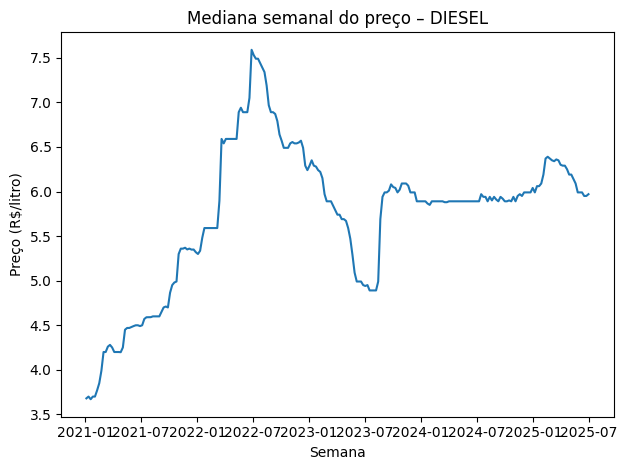

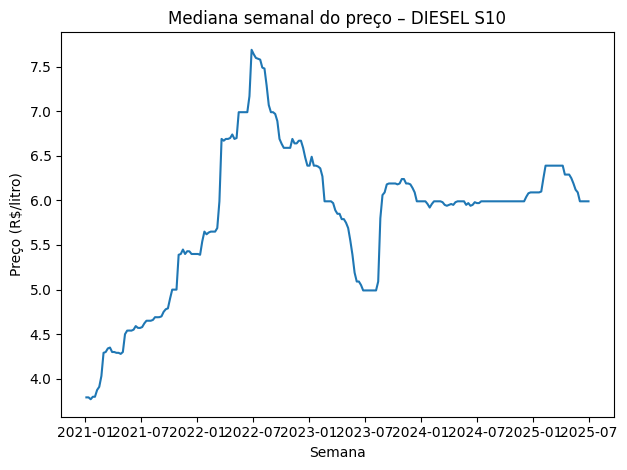

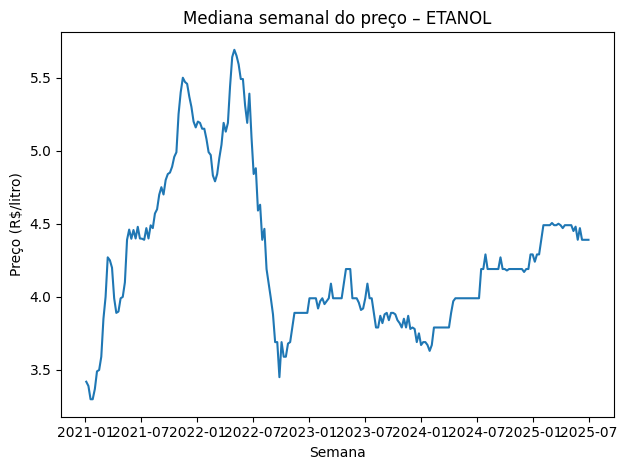

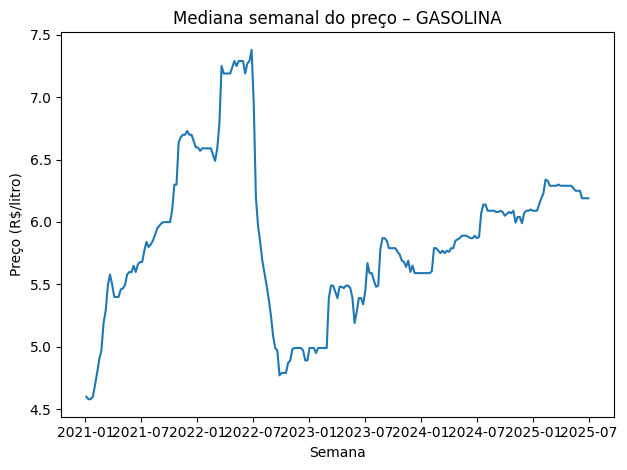

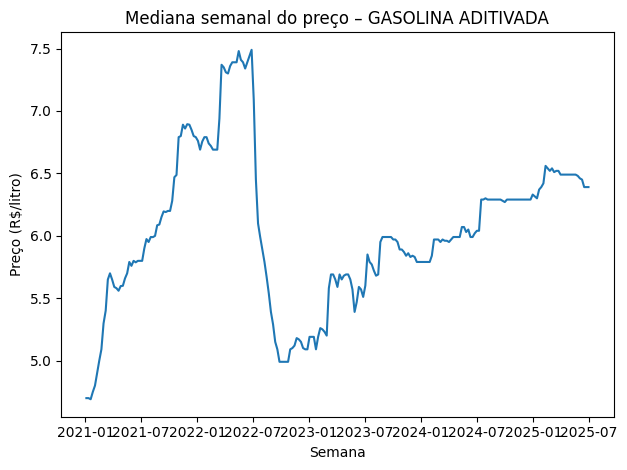

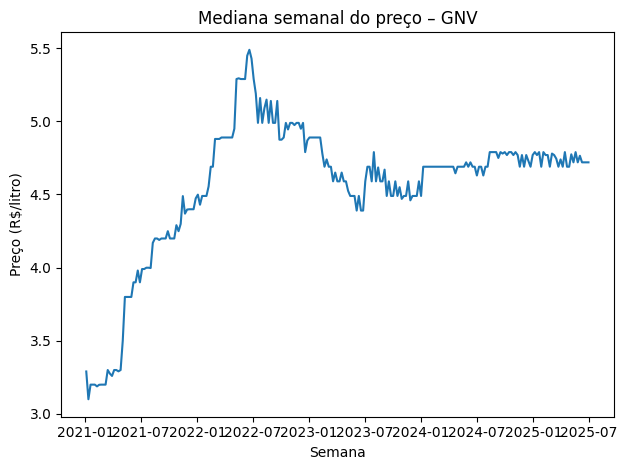


=== Outliers (regra IQR) nas medianas semanais por produto ===
           produto  level_1  mediana_preco
            DIESEL       q1         5.3270
            DIESEL       q3         6.1900
            DIESEL      iqr         0.8630
            DIESEL  lim_inf         4.0325
            DIESEL  lim_sup         7.4845
            DIESEL outliers        12.0000
        DIESEL S10       q1         5.3990
        DIESEL S10       q3         6.2800
        DIESEL S10      iqr         0.8810
        DIESEL S10  lim_inf         4.0775
        DIESEL S10  lim_sup         7.6015
        DIESEL S10 outliers        10.0000
            ETANOL       q1         3.8900
            ETANOL       q3         4.4900
            ETANOL      iqr         0.6000
            ETANOL  lim_inf         2.9900
            ETANOL  lim_sup         5.3900
            ETANOL outliers        11.0000
          GASOLINA       q1         5.4900
          GASOLINA       q3         6.1900
          GASOLINA      iqr      

<Figure size 640x480 with 0 Axes>

In [19]:
# =========================================================
# 4) Diagnósticos simples por Produto
#    - Sazonalidade/Autocorrelação: correlograma (semanas)
#    - Tendência visual: gráfico de linha
#    - Outliers: regra IQR sobre as medianas semanais
# =========================================================

import math

produtos = weekly["produto"].dropna().unique()

# (4a) Gráficos de série temporal (1 por produto)
for p in produtos:
    serie = weekly.loc[weekly["produto"] == p, ["semana","mediana_preco"]].dropna()
    if serie.empty:
        continue
    plt.figure()
    plt.plot(serie["semana"], serie["mediana_preco"])
    plt.title(f"Mediana semanal do preço – {p}")
    plt.xlabel("Semana")
    plt.ylabel("Preço (R$/litro)")
    plt.tight_layout()
    plt.show()

# (4b) Outliers via IQR nas medianas semanais (por produto)
def outlier_iqr(x):
    x = x.dropna()
    if x.empty:
        return pd.Series({"q1":np.nan,"q3":np.nan,"iqr":np.nan,"lim_inf":np.nan,"lim_sup":np.nan,"outliers":0})
    q1 = np.nanpercentile(x, 25)
    q3 = np.nanpercentile(x, 75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5*iqr
    lim_sup = q3 + 1.5*iqr
    n_out = ((x < lim_inf) | (x > lim_sup)).sum()
    return pd.Series({"q1":q1,"q3":q3,"iqr":iqr,"lim_inf":lim_inf,"lim_sup":lim_sup,"outliers":int(n_out)})

out_stats = weekly.groupby("produto")["mediana_preco"].apply(outlier_iqr).reset_index()
print("\n=== Outliers (regra IQR) nas medianas semanais por produto ===")
print(out_stats.to_string(index=False))

# (4c) Correlograma simples (autocorrelação) – requer statsmodels (opcional)
try:
    from statsmodels.tsa.stattools import acf
    for p in produtos:
        serie = weekly.loc[weekly["produto"] == p, ["semana","mediana_preco"]].dropna()
        if len(serie) < 10:
            continue
        # ordena por tempo e pega somente valores
        y = serie.sort_values("semana")["mediana_preco"].values
        # até 52 defasagens (1 ano aproximadamente)
        nlags = min(52, len(y)-2)
        if nlags <= 1:
            continue
        acf_vals = acf(y, nlags=nlags, fft=True, missing="conservative")
        plt.figure()
        plt.stem(range(len(acf_vals)), acf_vals, use_line_collection=True)
        plt.title(f"ACF das medianas semanais – {p}")
        plt.xlabel("Defasagem (semanas)")
        plt.ylabel("Autocorrelação")
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("\n[AVISO] statsmodels não disponível para ACF. Para ver correlogramas, instale: pip install statsmodels")
    print(f"Detalhes: {e}")

In [22]:
df.head(1)

,regiao,uf,municipio,revenda,cnpj,logradouro,numero,complemento,bairro,cep,produto,data,preco_venda,preco_compra,unidade,bandeira,ano,mes_dt,sem_dt
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,None,JARDIM ZULMIRA,18061-000,GASOLINA,2023-07-03,4.87,NaN,R$ / litro,BRANCA,2023,2023-07-01,2023-06-27


In [23]:
# =========================================================
# 5) Corte temporal para modelagem (treino <= 2024-12-31; teste = 2025)
## =========================================================

lim_treino = pd.Timestamp("2024-12-31")
lim_teste_ini = pd.Timestamp("2025-01-01")
lim_teste_fim = pd.Timestamp("2025-06-30")

weekly["particao"] = np.where(
    weekly["semana"] <= lim_treino, "treino",
    np.where((weekly["semana"] >= lim_teste_ini) & (weekly["semana"] <= lim_teste_fim), "teste_2025H1", "fora")
)

resumo_particao = weekly.pivot_table(index="produto", columns="particao", values="mediana_preco", aggfunc="count").fillna(0).astype(int)
print("\n=== Contagem de semanas por partição (treino/teste) ===")
print(resumo_particao.to_string())

# Salva a base já com a partição marcada
weekly.to_csv("out/mediana_semanal_por_produto_com_particao.csv", index=False, encoding="utf-8")
print("\nArquivos gerados:")
print(f"- {weekly_path.resolve()}")
print(f"- {Path('out/mediana_semanal_por_produto_com_particao.csv').resolve()}")


=== Contagem de semanas por partição (treino/teste) ===
particao            teste_2025H1  treino
produto                                 
DIESEL                        26     209
DIESEL S10                    26     209
ETANOL                        26     209
GASOLINA                      26     209
GASOLINA ADITIVADA            26     209
GNV                           26     209

Arquivos gerados:
- /home/wsl/tcc_lubricants_anp/out/mediana_semanal_por_produto.csv
- /home/wsl/tcc_lubricants_anp/out/mediana_semanal_por_produto_com_particao.csv


In [24]:
# =========================================================
# 6) Regressão Linear SIMPLES (por produto): y ~ t
#     - Sem lags, sem Fourier, sem dummies extras.
#     - Treino: 2021-01-01 até 2024-12-31
#     - Teste : 2025-01-01 até 2025-06-30 (já marcado em 'weekly["particao"]' como 'teste_2025H1')
# =========================================================

import statsmodels.api as sm


OUTDIR = Path("out/modelo_linear_simples")
OUTDIR.mkdir(parents=True, exist_ok=True)

TARGET = "mediana_preco"
TIME   = "semana"

# ---------- 6.1 Preparação ----------
weekly = weekly.copy()
weekly[TIME] = pd.to_datetime(weekly[TIME], errors="coerce")
weekly = weekly.dropna(subset=[TARGET, TIME, "produto", "particao"]).copy()
weekly = weekly.sort_values(["produto", TIME]).copy()
weekly = weekly.loc[weekly[TARGET] > 0].copy()

# Tendência temporal (dias desde o início do conjunto) — único preditor
t0 = weekly[TIME].min()
weekly["t"] = (weekly[TIME] - t0).dt.days.astype("int32")

# Split temporal já marcado no passo anterior
train = weekly.loc[weekly["particao"] == "treino"].copy()
test  = weekly.loc[weekly["particao"] == "teste_2025H1"].copy()

if train.empty or test.empty:
    raise ValueError(f"Split vazio. train={len(train)}, test={len(test)} — verifique 'particao'.")

In [25]:
train.sample(5)

,produto,semana,mediana_preco,n_observacoes,particao,t
554,ETANOL,2022-08-15,4.1900,5025,treino,588
995,GASOLINA ADITIVADA,2022-01-24,6.7900,3586,treino,385
1329,GNV,2023-12-18,4.4900,404,treino,1078
258,DIESEL S10,2021-06-14,4.5900,3204,treino,161
486,ETANOL,2021-04-26,3.9895,3098,treino,112


In [26]:
test.head(5)

,produto,semana,mediana_preco,n_observacoes,particao,t
209,DIESEL,2025-01-06,5.99,1630,teste_2025H1,1463
210,DIESEL,2025-01-13,6.06,1662,teste_2025H1,1470
211,DIESEL,2025-01-20,6.06,1713,teste_2025H1,1477
212,DIESEL,2025-01-27,6.09,1761,teste_2025H1,1484
213,DIESEL,2025-02-03,6.19,1651,teste_2025H1,1491


In [27]:
# ---------- 6.2 Ajuste por PRODUTO: y ~ t ----------
coefs = []
preds = []

for prod, gtr in train.groupby("produto"):
    gte = test.loc[test["produto"] == prod].copy()
    # precisa de pelo menos 2 pontos para ajustar y ~ t
    if len(gtr) < 2 or gte.empty:
        continue

    X_tr = sm.add_constant(gtr["t"].astype(float))
    y_tr = gtr[TARGET].astype(float)

    model = sm.OLS(y_tr, X_tr).fit()  # OLS simples, sem robustez (modelo "puro")

    # salva coeficientes e qualidade de ajuste no TREINO
    coefs.append({
        "produto": prod,
        "intercepto": model.params.get("const", np.nan),
        "coef_t": model.params.get("t", np.nan),
        "R2_treino": model.rsquared,
        "n_treino": int(model.nobs)
    })

    # previsões no TESTE (2025H1)
    X_te = sm.add_constant(gte["t"].astype(float))
    gte["y_hat"] = model.predict(X_te)
    gte["y_obs"] = gte[TARGET].astype(float)
    preds.append(gte[["produto", TIME, "y_obs", "y_hat"]])

# Consolida saídas
coef_df = pd.DataFrame(coefs).sort_values("produto")
pred_df = pd.concat(preds, axis=0).sort_values(["produto", TIME]) if preds else pd.DataFrame()


In [28]:
# ---------- 6.3 Métricas ----------
def _metrics(df):
    if df.empty:
        return np.nan, np.nan, np.nan
    y  = df["y_obs"].values
    yh = df["y_hat"].values
    mae  = np.mean(np.abs(yh - y))
    rmse = np.sqrt(np.mean((yh - y) ** 2))
    mape = np.mean(np.abs(yh - y) / y) * 100
    return mae, rmse, mape

MAE, RMSE, MAPE = _metrics(pred_df)

per_prod = (
    pred_df.groupby("produto")
           .apply(lambda d: pd.Series({
               "MAE":  np.mean(np.abs(d["y_hat"] - d["y_obs"])),
               "RMSE": np.sqrt(np.mean((d["y_hat"] - d["y_obs"])**2)),
               "MAPE": np.mean(np.abs(d["y_hat"] - d["y_obs"]) / d["y_obs"]) * 100,
               "n_sem": len(d)
           }))
           .reset_index()
           .sort_values("produto")
)

print("\n=== Regressão linear simples (y ~ t) — TESTE 2025-H1 ===")
print(f"MAE={MAE:.3f}  RMSE={RMSE:.3f}  MAPE={MAPE:.2f}%")

print("\n=== Métricas por produto (teste) ===")
print(per_prod.round(3).to_string(index=False))


=== Regressão linear simples (y ~ t) — TESTE 2025-H1 ===
MAE=0.400  RMSE=0.428  MAPE=7.29%

=== Métricas por produto (teste) ===
           produto   MAE  RMSE   MAPE  n_sem
            DIESEL 0.291 0.343  4.783   26.0
        DIESEL S10 0.343 0.389  5.594   26.0
            ETANOL 0.574 0.580 12.911   26.0
          GASOLINA 0.431 0.436  6.887   26.0
GASOLINA ADITIVADA 0.433 0.438  6.690   26.0
               GNV 0.327 0.332  6.903   26.0


A regressão linear simples do preço em função do tempo (y ~ t), treinada de 2021-01-01 a 2024-12-31 e avaliada em 2025-H1, apresentou MAE=R$ 0,400/L e MAPE=7,29%. O desempenho por produto variou entre ~R$ 0,29 (Diesel) e ~R$ 0,57 (Etanol). O resultado decorre das limitações inerentes ao modelo: (i) uma tendência linear única não captura quebras de patamar e choques regulatórios; (ii) a dinâmica semanal de preços exibe alta persistência e sazonalidade suave; (iii) há heterogeneidade entre combustíveis. Em contraste, um baseline ingênuo que replica o último valor semanal (lag1) supera a regressão linear em curto prazo, o que é consistente com séries altamente inerciais. Assim, a regressão linear simples é útil como referência didática e para mensurar tendência média, mas não é adequada como preditor operacional. Trabalhos subsequentes devem incorporar termos de memória (defasagens), sazonalidade e/ou variáveis exógenas (Brent, câmbio, política tributária) para ganhos substanciais de acurácia.

[('GNV', np.float64(0.3031933607509333)), ('DIESEL', np.float64(0.22306373946520675)), ('DIESEL S10', np.float64(0.22073913421871882)), ('ETANOL', np.float64(0.12645885600502516)), ('GASOLINA ADITIVADA', np.float64(0.0015157559869289905)), ('GASOLINA', np.float64(4.522990272604055e-05))]


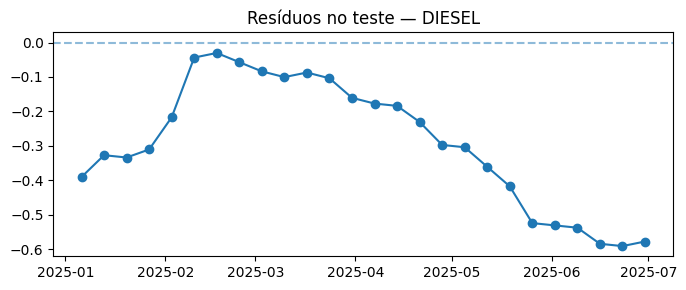

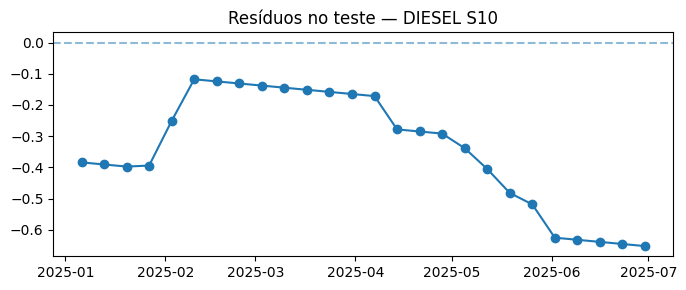

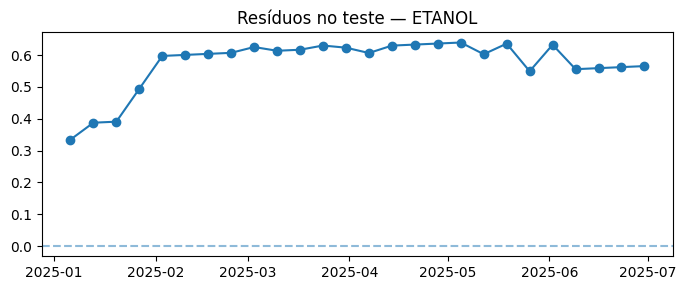

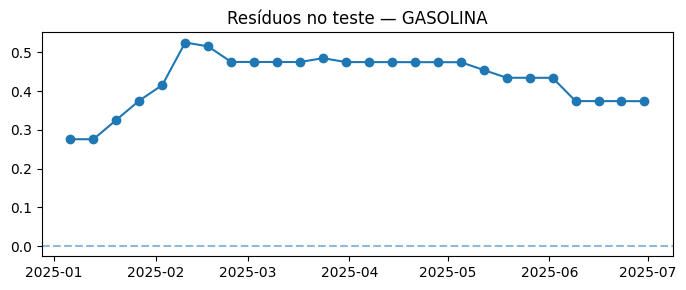

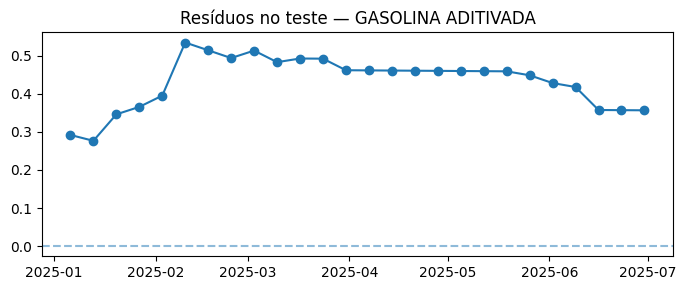

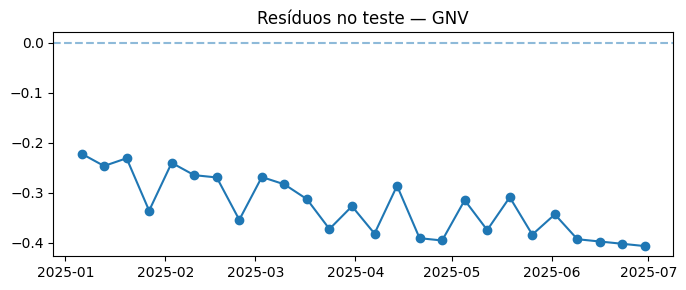

In [29]:
# R² por produto no treino (para mostrar fraca explicação linear)
import statsmodels.api as sm
r2_por_prod = []
for prod, g in train.groupby("produto"):
    X = sm.add_constant(g["t"].astype(float))
    y = g[TARGET].astype(float)
    r2_por_prod.append((prod, sm.OLS(y, X).fit().rsquared))
print(sorted(r2_por_prod, key=lambda x: x[1], reverse=True))

# Resíduos vs tempo no teste (padrão em leque indica variância não constante)
import matplotlib.pyplot as plt
pred_df["resid"] = pred_df["y_obs"] - pred_df["y_hat"]
for prod, g in pred_df.groupby("produto"):
    g = g.sort_values(TIME)
    plt.figure(figsize=(7,3))
    plt.plot(g[TIME], g["resid"], marker="o")
    plt.axhline(0, ls="--", alpha=.5); plt.title(f"Resíduos no teste — {prod}")
    plt.tight_layout(); plt.show()

avaliacao do modelo de treino: 
histograma da resposta (distribuicao)
boxplot dos valores mediados para cada produto
booxplot por UF
boxplot regional tambem

avaliacao do modelo
histograma dos residuos
qqplot
teste de normalidade 
plot dos residuos para o treino - uma nnuvem de pontos em torno do zero e um grafico dos residuos de valores ajustados
adicionar o mensal de janeiro/21 ate dezembro de 24 - numeral 1, 2, 3, 4....
preco de referencia - fazer de maneira regional
do preço menor ou maior de referencia por combustivel
qual uf na media o combustivel é mais barato - verificar os valores comparando para saber a diferenca entre eles. 
se for o caso
transformacao logaritimica para retornar usar o exponencial

In [33]:
# === Heterocedasticidade (BP + "White leve") e COEFs do modelo linear simples (y ~ t) por produto ===
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera

TARGET = "mediana_preco"
TIME   = "semana"


# 2) Ajuste por produto e testes
rows = []
for prod, gtr in train.groupby("produto", sort=True):
    if len(gtr) < 2:
        continue

    # Modelo OLS simples: y ~ t
    X = sm.add_constant(gtr["t"].astype(float))
    y = gtr[TARGET].astype(float)
    mdl = sm.OLS(y, X).fit()

    # Coeficientes básicos
    b0   = mdl.params.get("const", np.nan)
    bt   = mdl.params.get("t", np.nan)
    se_b0= mdl.bse.get("const", np.nan)
    se_bt= mdl.bse.get("t", np.nan)
    p_b0 = mdl.pvalues.get("const", np.nan)
    p_bt = mdl.pvalues.get("t", np.nan)
    r2   = mdl.rsquared
    nobs = int(mdl.nobs)

    # --- Breusch–Pagan (testa var(resíduos) ~ X)
    # Usamos X "original" (const + t). Também é comum usar [const, y_hat]
    bp_stat, bp_p, _, _ = het_breuschpagan(mdl.resid, X)

    # --- "White leve" (auxiliary regression com 1, y_hat, y_hat^2)
    # Evita explosão de memória do White completo.
    y_hat = mdl.fittedvalues.to_numpy()
    y_aux = (mdl.resid.to_numpy())**2
    Z = np.column_stack([np.ones_like(y_hat), y_hat, y_hat**2])
    aux = sm.OLS(y_aux, Z).fit()
    # F-teste conjunto para (y_hat, y_hat^2) ≠ 0  (exclui a constante)
    R = np.array([[0,1,0],
                  [0,0,1]], dtype=float)
    ftest = aux.f_test(R)
    whiteF = float(ftest.fvalue)
    whiteP = float(ftest.pvalue)

    # (Opcional) Normalidade dos resíduos — útil para relatório
    jb_stat, jb_p, skew, kurt = jarque_bera(mdl.resid)

    rows.append({
        "produto": prod,
        "intercepto": b0,
        "coef_t(dia)": bt,        # variação média R$/dia
        "se_intercepto": se_b0,
        "se_coef_t": se_bt,
        "p_intercepto": p_b0,
        "p_coef_t": p_bt,
        "R2_treino": r2,
        "n_treino": nobs,
        "BP_stat": bp_stat,
        "BP_pvalue": bp_p,
        "White_leve_F": whiteF,
        "White_leve_p": whiteP,
        "JB_stat": jb_stat,
        "JB_pvalue": jb_p
    })

result_prod = pd.DataFrame(rows).sort_values("produto")

print("\n=== COEFICIENTES e TESTES por produto (treino 2021–2024) ===")
cols_show = ["produto", "intercepto", "coef_t(dia)", "se_coef_t", "p_coef_t",
             "R2_treino", "n_treino", "BP_pvalue", "White_leve_p", "JB_pvalue"]
print(result_prod[cols_show].round(6).to_string(index=False))
print("\nTop 6 produtos com maior evidência de heterocedasticidade (BP p-value):")
print(result_prod.sort_values("BP_pvalue").head(6)[["produto","BP_stat","BP_pvalue"]].round(6).to_string(index=False))



=== COEFICIENTES e TESTES por produto (treino 2021–2024) ===
           produto  intercepto  coef_t(dia)  se_coef_t  p_coef_t  R2_treino  n_treino  BP_pvalue  White_leve_p  JB_pvalue
            DIESEL    4.983619     0.000955   0.000124  0.000000   0.223064       209   0.000001           0.0   0.000008
        DIESEL S10    5.066591     0.000962   0.000126  0.000000   0.220739       209   0.000001           0.0   0.000008
            ETANOL    4.583497    -0.000463   0.000085  0.000000   0.126459       209   0.000000           0.0   0.069550
          GASOLINA    5.799178     0.000010   0.000105  0.923008   0.000045       209   0.000000           0.0   0.006107
GASOLINA ADITIVADA    5.937489     0.000058   0.000104  0.575697   0.001516       209   0.000000           0.0   0.010550
               GNV    4.054960     0.000654   0.000069  0.000000   0.303193       209   0.000000           0.0   0.505186

Top 6 produtos com maior evidência de heterocedasticidade (BP p-value):
           

intercepto: preço estimado quando t=0 (primeira semana da série)
coef_t(dia): inclinação da reta em R$/dia. Multiplique por 7 para R$/semana ou por 365,25 para R$/ano.
se_coef_t / p_coef_t: erro-padrão e p-valor do coeficiente de t. p<0,05 → tendência linear estatisticamente significativa.
R2_treino: fração da variação explicada pela tendência linear no treino (2021–2024). Baixo R² indica que “apenas uma reta” explica pouco do comportamento.
n_treino: nº de semanas (≈209 para cada produto).
BP_pvalue: p-valor do Breusch–Pagan. p<0,05 sugere heterocedasticidade.
White_leve_p: “White leve” (auxiliar com 1,𝑦^,𝑦^21,y^,y^2). p≈0 confirma o alerta de heterocedasticidade sem custar memória.
JB_pvalue: p-valor do Jarque–Bera. p<0,05 → resíduos não normais (caudas/excesso de curtose); p grande → normalidade não rejeitada.

Leitura por produto (tradução do coeficiente para ano)
Aproximação: efeito anual ≈ coef_t(dia) × 365,25.
DIESEL: 0,000955 R$/dia → ~R$ 0,35/ano ↑ (p<0,001). R²=0,223 → a reta explica ~22% da variação; há bastante coisa não-linear/sazonal. Heterocedasticidade (BP≈0). Resíduos não normais (JB p≈0).
DIESEL S10: 0,000962 → ~R$ 0,35/ano ↑ (p<0,001). R²=0,221. Mesma leitura de diagnóstico de cima.
ETANOL: −0,000463 → ~−R$ 0,17/ano ↓ (p<0,001). R²=0,126 (tendência explica pouco). Heterocedasticidade forte (BP≈0). JB p=0,069 → não rejeita normalidade (ok).
GASOLINA: 0,000010 → ~R$ 0,004/ano (≈zero; p=0,923). Sem tendência linear detectável. R²≈0.00005 (reta não explica). Heterocedasticidade (BP≈0). Resíduos não normais (JB p≈0).
GASOLINA ADITIVADA: 0,000058 → ~R$ 0,02/ano (ns; p=0,576). R²≈0,0015. Heterocedasticidade (BP≈0). Resíduos não normais (JB p≈0,01).
GNV: 0,000654 → ~R$ 0,24/ano ↑ (p<0,001). R²=0,303 (melhor entre os produtos). Heterocedasticidade (BP≈0). JB p=0,505 → normalidade OK.

“Top 6” de heterocedasticidade (BP)
Todos apresentam p≈0 (forte evidência). A ordem (GNV, Etanol, Gasolina Aditivada, Gasolina, Diesel, Diesel S10) indica onde o problema é mais agudo, mas na prática é universal aqui.
Conclusões e implicações
Tendência linear é significativa para Diesel, Diesel S10, Etanol e GNV; não é para Gasolina e Gasolina Aditivada (p>0,05).
R² baixo em geral (0,00–0,30): uma reta no tempo não captura bem quebras de patamar, choques e sazonalidade.
Heterocedasticidade existe em todos (BP/White≈0): não confie em erros-padrão clássicos; reporte robustos (HC3) ou HAC.
Normalidade dos resíduos: Etanol e GNV não rejeitam normalidade; os demais rejeitam. Com N grande, a normalidade é menos crítica, mas reforce a inferência com erros robustos.

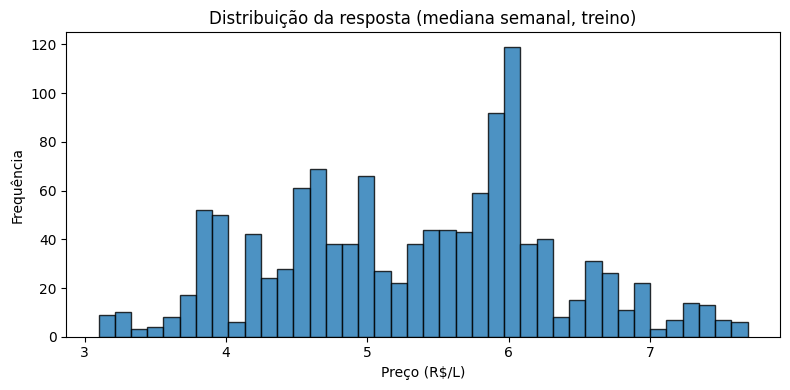

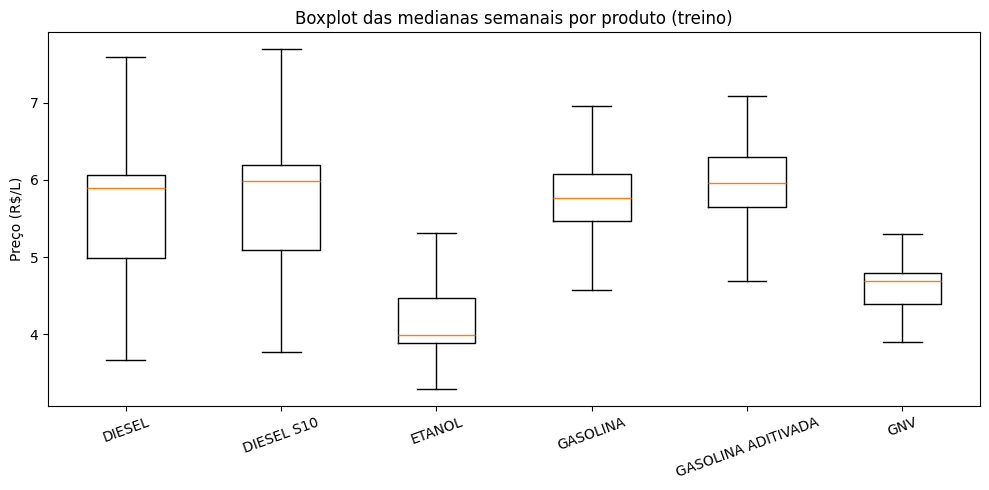

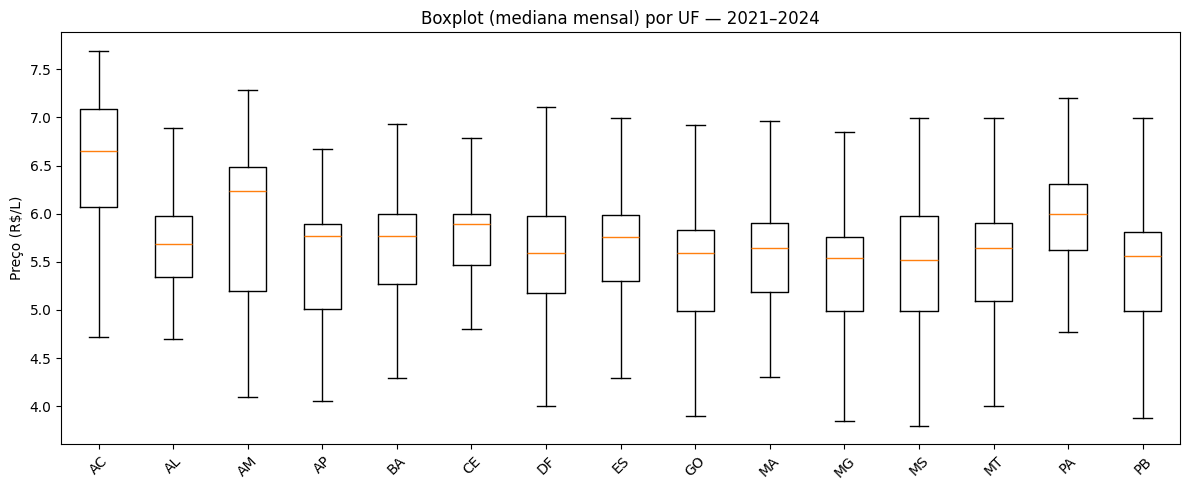

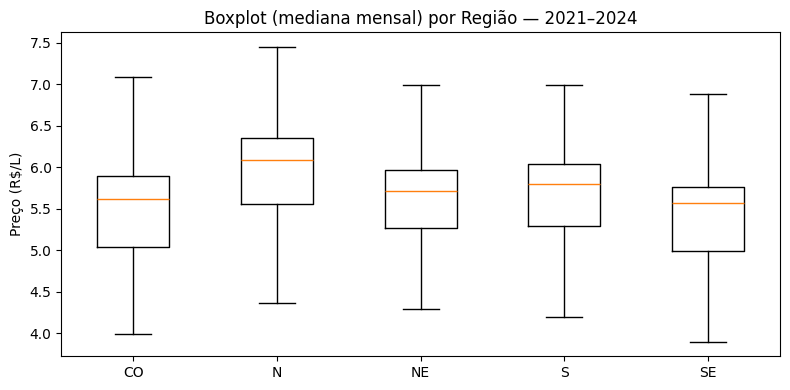

In [ ]:
# Bloco A — auto-contido e robusto
# Requisitos mínimos:
#   - train com colunas: ['produto','semana','mediana_preco',...]
#   - df (base crua) com: ['data','preco_venda','uf','regiao',...]
# Ajuste os renames abaixo se seus nomes forem outros.

# ---- Config nomes (train) ----
COL_PRECO_SEM = "mediana_preco"
COL_TIME_WEEK = "semana"

# ---- Config nomes (df cru) ----
COL_TIME_RAW  = "data"
COL_PRECO_RAW = "preco_venda"

# ---------- Garantias básicas ----------
train = train.copy()
train[COL_TIME_WEEK] = pd.to_datetime(train[COL_TIME_WEEK], errors="coerce")
train = train.dropna(subset=[COL_TIME_WEEK, COL_PRECO_SEM])

# Se sua base crua tiver nomes diferentes, mapeie aqui:
if "df" in globals():
    df_21_24 = df.copy()

    # Renomes comuns (ajuste se necessário)
    df_21_24 = df_21_24.rename(columns={
        "Data da Coleta": "data",
        "Valor de Venda": "preco_venda",
        "Regiao - Sigla": "regiao",
        "Estado - Sigla": "uf"
    })

    # Tipos e recorte temporal
    df_21_24[COL_TIME_RAW] = pd.to_datetime(df_21_24[COL_TIME_RAW], errors="coerce")
    df_21_24 = df_21_24.dropna(subset=[COL_TIME_RAW, COL_PRECO_RAW])
    df_21_24 = df_21_24.loc[
        (df_21_24[COL_TIME_RAW] >= "2021-01-01") &
        (df_21_24[COL_TIME_RAW] <= "2024-12-31")
    ].copy()

# =========================================================
# A.1) Histograma da resposta (distribuição no treino, semanal)
# =========================================================
plt.figure(figsize=(8,4))
plt.hist(train[COL_PRECO_SEM].dropna(), bins=40, edgecolor="k", alpha=.8)
plt.title("Distribuição da resposta (mediana semanal, treino)")
plt.xlabel("Preço (R$/L)"); plt.ylabel("Frequência")
plt.tight_layout(); plt.show()

# =========================================================
# A.2) Boxplot (medianas semanais) por produto (treino)
# =========================================================
prods = sorted(train["produto"].dropna().unique())
data_bp = [train.loc[train["produto"]==p, COL_PRECO_SEM].dropna().values for p in prods]

plt.figure(figsize=(10,5))
plt.boxplot(data_bp, labels=prods, showfliers=False)
plt.title("Boxplot das medianas semanais por produto (treino)")
plt.ylabel("Preço (R$/L)")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

# =========================================================
# A.3) Boxplot por UF (a partir da base crua df_21_24)
#      - agrega para mediana MENSAL por UF
# =========================================================
if "df_21_24" in globals() and {"uf", COL_PRECO_RAW, COL_TIME_RAW}.issubset(df_21_24.columns):
    df_21_24["mes"] = df_21_24[COL_TIME_RAW].dt.to_period("M").astype(str)
    uf_mensal = df_21_24.groupby(["uf","mes"], as_index=False)[COL_PRECO_RAW].median()

    # Top 15 UFs por nº de meses presentes (para visual limpo)
    top_ufs = uf_mensal["uf"].value_counts().head(15).index.tolist()
    uf_mensal_top = uf_mensal[uf_mensal["uf"].isin(top_ufs)].copy()

    ufs_ord = sorted(uf_mensal_top["uf"].unique())
    data_bp_uf = [uf_mensal_top.loc[uf_mensal_top["uf"]==u, COL_PRECO_RAW].values for u in ufs_ord]

    plt.figure(figsize=(12,5))
    plt.boxplot(data_bp_uf, labels=ufs_ord, showfliers=False)
    plt.title("Boxplot (mediana mensal) por UF — 2021–2024")
    plt.ylabel("Preço (R$/L)")
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# =========================================================
# A.4) Boxplot por Região (a partir de df_21_24)
# =========================================================
if "df_21_24" in globals() and {"regiao", COL_PRECO_RAW, "mes"}.issubset(df_21_24.columns):
    reg_mensal = df_21_24.groupby(["regiao","mes"], as_index=False)[COL_PRECO_RAW].median()
    regs_ord = sorted(reg_mensal["regiao"].unique())
    data_bp_reg = [reg_mensal.loc[reg_mensal["regiao"]==r, COL_PRECO_RAW].values for r in regs_ord]

    plt.figure(figsize=(8,4))
    plt.boxplot(data_bp_reg, labels=regs_ord, showfliers=False)
    plt.title("Boxplot (mediana mensal) por Região — 2021–2024")
    plt.ylabel("Preço (R$/L)")
    plt.tight_layout(); plt.show()


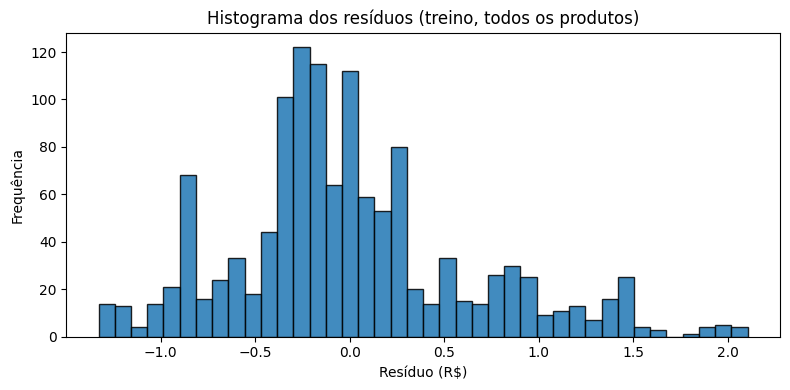

<Figure size 500x500 with 0 Axes>

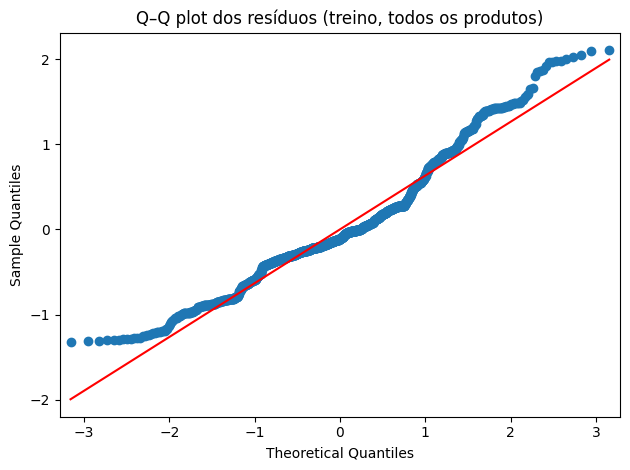

[Jarque–Bera — geral] stat=115.50, p=8.325e-26, skew=0.688, kurt=3.562

[Jarque–Bera — por produto]
            DIESEL: JB stat=23.43, p=8.163e-06, skew=0.815, kurt=3.178
        DIESEL S10: JB stat=23.48, p=7.977e-06, skew=0.819, kurt=3.127
            ETANOL: JB stat=5.33, p=0.06955, skew=0.371, kurt=3.246
          GASOLINA: JB stat=10.20, p=0.006107, skew=0.539, kurt=3.091
GASOLINA ADITIVADA: JB stat=9.10, p=0.01055, skew=0.511, kurt=3.048
               GNV: JB stat=1.37, p=0.5052, skew=0.148, kurt=3.263


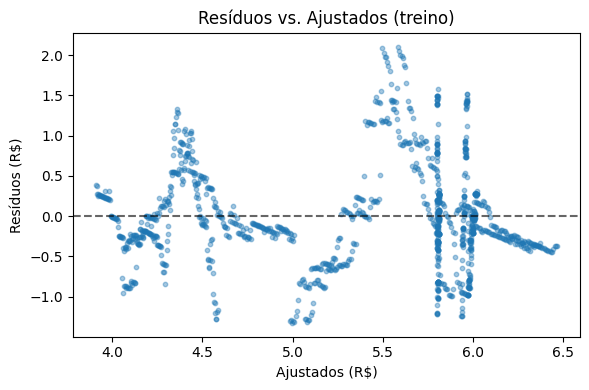

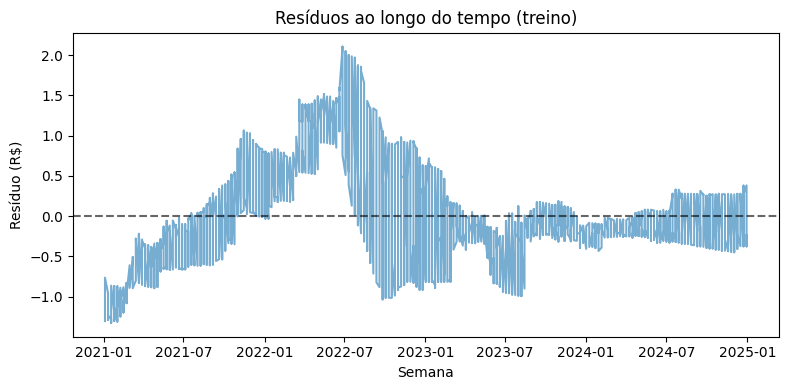

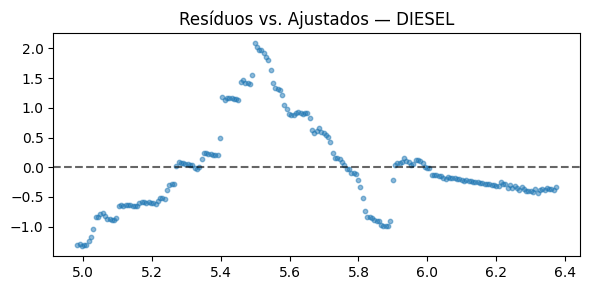

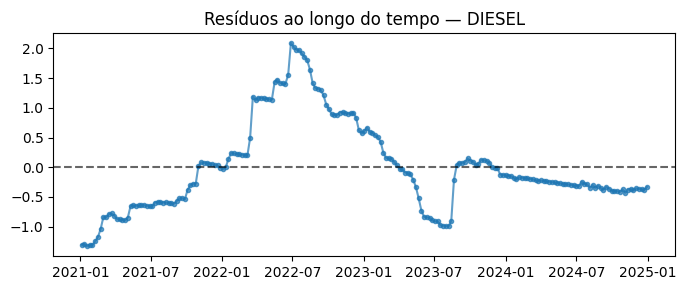

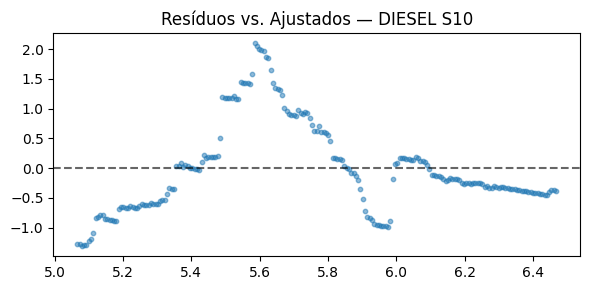

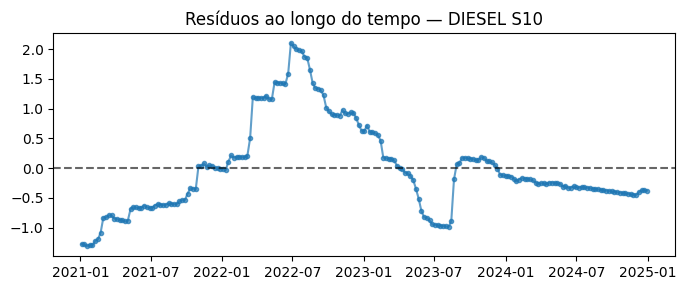

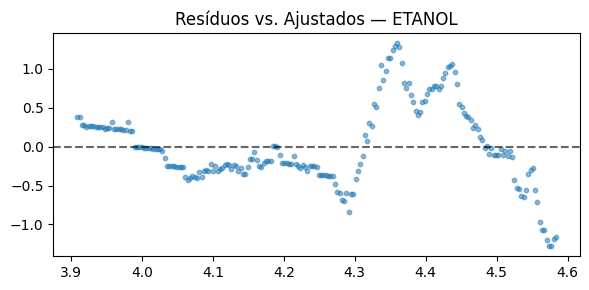

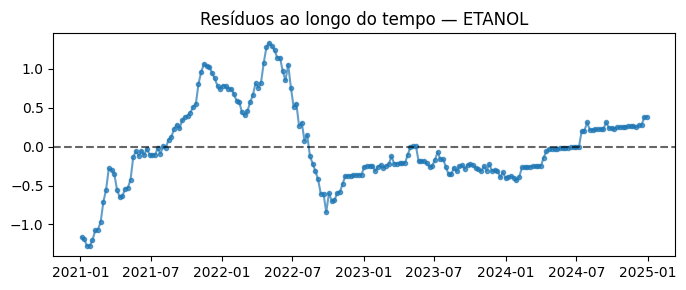

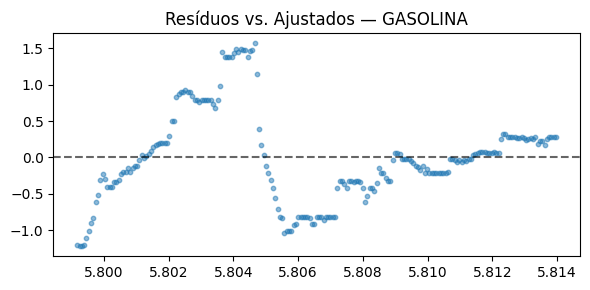

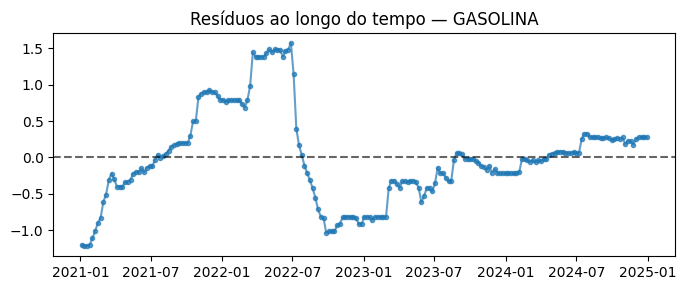

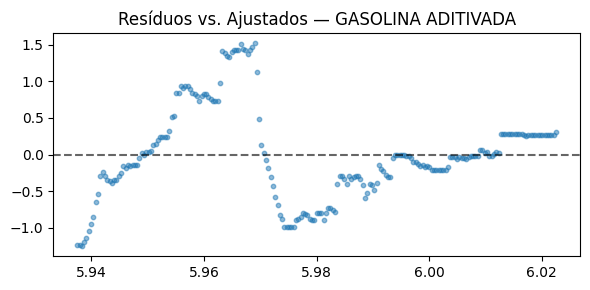

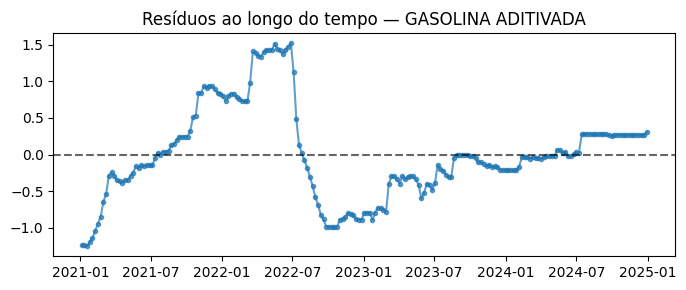

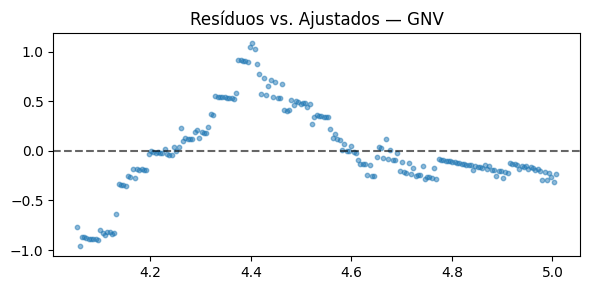

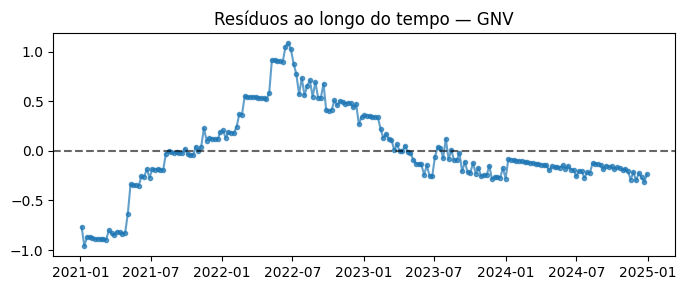

In [39]:
# =========================================================
# B.1) Ajuste OLS por produto no treino (y ~ t) e coleta resíduos/ajustados
# =========================================================
res_all = []  # armazenar (produto, semana, y, yhat, resid, t)

for prod, g in train.groupby("produto"):
    if len(g) < 2:
        continue
    X = sm.add_constant(g["t"].astype(float))
    y = g[COL_PRECO_SEM].astype(float)
    mdl = sm.OLS(y, X).fit()   # modelo "puro"

    yhat = mdl.predict(X)
    resid = y - yhat

    tmp = pd.DataFrame({
        "produto": prod,
        "semana": g[COL_TIME_WEEK].values,
        "y": y.values,
        "yhat": yhat.values,
        "resid": resid.values,
        "t": g["t"].values
    })
    res_all.append(tmp)

res_all = pd.concat(res_all, axis=0, ignore_index=True)

# =========================================================
# B.2) Histograma dos resíduos (geral)
# =========================================================
plt.figure(figsize=(8,4))
plt.hist(res_all["resid"].dropna(), bins=40, edgecolor="k", alpha=.85)
plt.title("Histograma dos resíduos (treino, todos os produtos)")
plt.xlabel("Resíduo (R$)"); plt.ylabel("Frequência")
plt.tight_layout(); plt.show()

# =========================================================
# B.3) Q–Q plot (resíduos gerais)
# =========================================================
plt.figure(figsize=(5,5))
sm.ProbPlot(res_all["resid"].dropna()).qqplot(line="s")
plt.title("Q–Q plot dos resíduos (treino, todos os produtos)")
plt.tight_layout(); plt.show()

# =========================================================
# B.4) Teste de normalidade (Jarque–Bera) — geral e por produto
# =========================================================
jb_stat, jb_p, skew, kurt = jarque_bera(res_all["resid"].dropna())
print(f"[Jarque–Bera — geral] stat={jb_stat:.2f}, p={jb_p:.4g}, skew={skew:.3f}, kurt={kurt:.3f}")

print("\n[Jarque–Bera — por produto]")
for prod, g in res_all.groupby("produto"):
    if g["resid"].notna().sum() < 8:
        continue
    jbs, jbp, sk, ku = jarque_bera(g["resid"].dropna())
    print(f"{prod:>18}: JB stat={jbs:.2f}, p={jbp:.4g}, skew={sk:.3f}, kurt={ku:.3f}")

# =========================================================
# B.5) Resíduos vs. ajustados e Resíduos vs. tempo (nuvem)
# =========================================================
# Geral
plt.figure(figsize=(6,4))
plt.scatter(res_all["yhat"], res_all["resid"], alpha=.4, s=10)
plt.axhline(0, ls="--", color="k", alpha=.6)
plt.title("Resíduos vs. Ajustados (treino)")
plt.xlabel("Ajustados (R$)"); plt.ylabel("Resíduos (R$)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
# ordenar por tempo pra desenhar linha
r_sorted = res_all.sort_values("semana")
plt.plot(r_sorted["semana"], r_sorted["resid"], alpha=.6)
plt.axhline(0, ls="--", color="k", alpha=.6)
plt.title("Resíduos ao longo do tempo (treino)")
plt.xlabel("Semana"); plt.ylabel("Resíduo (R$)")
plt.tight_layout(); plt.show()

# Por produto (se quiser detalhar)
for prod, g in res_all.groupby("produto"):
    g = g.sort_values("semana")
    plt.figure(figsize=(6,3))
    plt.scatter(g["yhat"], g["resid"], alpha=.5, s=10)
    plt.axhline(0, ls="--", color="k", alpha=.6)
    plt.title(f"Resíduos vs. Ajustados — {prod}")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,3))
    plt.plot(g["semana"], g["resid"], marker="o", ms=3, alpha=.7)
    plt.axhline(0, ls="--", color="k", alpha=.6)
    plt.title(f"Resíduos ao longo do tempo — {prod}")
    plt.tight_layout(); plt.show()


In [ ]:
# C) Índice mensal 1..N (2021-01 a 2024-12) — versão à prova de pandas
#    Usa timestamp do 1º dia do mês e conta meses desde o mínimo

# 1) Garantir coluna mensal como início do mês (MS)
df_21_24["mes_dt"] = (
    pd.to_datetime(df_21_24[COL_TIME_RAW], errors="coerce")
      .dt.to_period("M")
      .dt.to_timestamp(how="start")  # 1º dia do mês
)

# 2) Índice sequencial de meses (1..N) desde o menor mês
base = df_21_24["mes_dt"].min()
df_21_24["mes_idx"] = (
    (df_21_24["mes_dt"].dt.year - base.year) * 12
    + (df_21_24["mes_dt"].dt.month - base.month)
    + 1
).astype("int32")

# 3) Exemplo: agregação mensal por produto (mediana)
mensal_prod = (
    df_21_24
      .groupby(["produto", "mes_dt", "mes_idx"], as_index=False)[COL_PRECO_RAW]
      .median()
      .rename(columns={COL_PRECO_RAW: "preco_mediano_mensal"})
)

print(mensal_prod.head())


  produto     mes_dt  mes_idx  preco_mediano_mensal
0  DIESEL 2021-01-01        1                 3.690
1  DIESEL 2021-02-01        2                 3.899
2  DIESEL 2021-03-01        3                 4.249
3  DIESEL 2021-04-01        4                 4.199
4  DIESEL 2021-05-01        5                 4.459


In [ ]:
# D.1) Referência regional (min/max) por produto
reg_ref = (
    df_21_24
      .assign(mes_dt=lambda d: d[COL_TIME_RAW].values.astype("datetime64[M]"))
      .groupby(["produto","regiao","mes_dt"], as_index=False)[COL_PRECO_RAW]
      .median()
      .rename(columns={COL_PRECO_RAW:"preco_mediano_mensal"})
)

# preço de referência (menor/maior) por produto-região no período 2021–2024
ref_reg_min = (
    reg_ref.groupby(["produto","regiao"], as_index=False)["preco_mediano_mensal"].median()
           .sort_values(["produto","preco_mediano_mensal"])
           .groupby("produto", as_index=False)
           .first()
           .rename(columns={"regiao":"regiao_mais_barata","preco_mediano_mensal":"ref_reg_min"})
)

ref_reg_max = (
    reg_ref.groupby(["produto","regiao"], as_index=False)["preco_mediano_mensal"].median()
           .sort_values(["produto","preco_mediano_mensal"], ascending=[True, False])
           .groupby("produto", as_index=False)
           .first()
           .rename(columns={"regiao":"regiao_mais_cara","preco_mediano_mensal":"ref_reg_max"})
)

reg_summary = ref_reg_min.merge(ref_reg_max, on="produto", how="outer")
reg_summary["spread_regional"] = reg_summary["ref_reg_max"] - reg_summary["ref_reg_min"]
print("\n=== Referência regional por produto (mediana mensal 2021–2024) ===")
print(reg_summary.to_string(index=False))

# =========================================================
# D.2) UF mais barata por produto e diferenças
# =========================================================
uf_ref = (
    df_21_24
      .assign(mes_dt=lambda d: d[COL_TIME_RAW].values.astype("datetime64[M]"))
      .groupby(["produto","uf","mes_dt"], as_index=False)[COL_PRECO_RAW]
      .median()
      .rename(columns={COL_PRECO_RAW:"preco_mediano_mensal"})
)

# mediana da mediana mensal por UF (resumo 2021–2024)
uf_medianas = (
    uf_ref.groupby(["produto","uf"], as_index=False)["preco_mediano_mensal"]
          .median()
          .rename(columns={"preco_mediano_mensal":"ref_uf"})
)

# UF mais barata e mais cara por produto
uf_min = uf_medianas.sort_values(["produto","ref_uf"]).groupby("produto", as_index=False).first()
uf_max = uf_medianas.sort_values(["produto","ref_uf"], ascending=[True, False]).groupby("produto", as_index=False).first()
uf_min = uf_min.rename(columns={"uf":"uf_mais_barata","ref_uf":"preco_min"})
uf_max = uf_max.rename(columns={"uf":"uf_mais_cara","ref_uf":"preco_max"})

uf_summary = uf_min.merge(uf_max, on="produto", how="outer")
uf_summary["spread_uf"] = uf_summary["preco_max"] - uf_summary["preco_min"]

# opcional: diferença para a 2ª mais barata (para ver “quão isolada” é a mais barata)
def diff_segunda_mais_barata(g):
    g = g.sort_values("ref_uf")
    if len(g) >= 2:
        return g.iloc[1]["ref_uf"] - g.iloc[0]["ref_uf"]
    return np.nan

delta2 = (
    uf_medianas.groupby("produto").apply(diff_segunda_mais_barata)
               .reset_index(name="delta_para_segunda_mais_barata")
)

uf_summary = uf_summary.merge(delta2, on="produto", how="left")

print("\n=== UF mais barata/cara por produto (mediana mensal 2021–2024) ===")
print(uf_summary.to_string(index=False))



=== Referência regional por produto (mediana mensal 2021–2024) ===
           produto regiao_mais_barata  ref_reg_min regiao_mais_cara  ref_reg_max  spread_regional
            DIESEL                 SE       5.7900                N       6.3450           0.5550
        DIESEL S10                 NE       5.8900                N       6.3225           0.4325
            ETANOL                 SE       3.9350                N       4.6900           0.7550
          GASOLINA                 SE       5.6095                N       6.1050           0.4955
GASOLINA ADITIVADA                 SE       5.8800                N       6.2850           0.4050
               GNV                 CO       3.8925                S       4.9800           1.0875

=== UF mais barata/cara por produto (mediana mensal 2021–2024) ===
           produto uf_mais_barata  preco_min uf_mais_cara  preco_max  spread_uf  delta_para_segunda_mais_barata
            DIESEL             SE     5.5800           AC     6.96

In [45]:
# =========================================================
# E) Exemplo de transformação logarítmica e back-transform
# =========================================================
# Exemplo no treino semanal (se quiser reavaliar normalidade/hetero em log)
train_log = train.loc[train[COL_PRECO_SEM] > 0].copy()
train_log["log_y"] = np.log(train_log[COL_PRECO_SEM])

# Ajuste por produto: log(y) ~ t
coefs_log = []
for prod, g in train_log.groupby("produto"):
    if len(g) < 2:
        continue
    X = sm.add_constant(g["t"].astype(float))
    y = g["log_y"].astype(float)
    mdl = sm.OLS(y, X).fit()

    # previsões em log e retorno ao nível (exponencial)
    yhat_log = mdl.predict(X)
    yhat_lvl = np.exp(yhat_log)

    coefs_log.append({
        "produto": prod,
        "intercepto_log": mdl.params.get("const", np.nan),
        "coef_t_log": mdl.params.get("t", np.nan),
        "R2_log": mdl.rsquared,
        "n": int(mdl.nobs)
    })

coefs_log = pd.DataFrame(coefs_log)
print("\n=== Regressão em log (log(y) ~ t) — resumo por produto ===")
print(coefs_log.to_string(index=False))



=== Regressão em log (log(y) ~ t) — resumo por produto ===
           produto  intercepto_log  coef_t_log   R2_log   n
            DIESEL        1.582229    0.000196 0.271841 209
        DIESEL S10        1.599015    0.000194 0.269735 209
            ETANOL        1.510374   -0.000099 0.114344 209
          GASOLINA        1.746077    0.000010 0.001410 209
GASOLINA ADITIVADA        1.770255    0.000017 0.004892 209
               GNV        1.384905    0.000164 0.325310 209


In [44]:
# 5) Exportar para CSV
out_path = Path("out/modelo_linear_simples")
out_path.mkdir(parents=True, exist_ok=True)
result_prod.to_csv(out_path / "coeficientes_e_testes_por_produto.csv", index=False, float_format="%.6g")
print(f"\n[OK] Tabela salva em: {(out_path / 'coeficientes_e_testes_por_produto.csv').resolve()}")


[OK] Tabela salva em: /home/wsl/tcc_lubricants_anp/out/modelo_linear_simples/coeficientes_e_testes_por_produto.csv
